# Credit Risk & Performance Analytics Dashboard
### Notebook 01 - Data Cleaning + Feature Engineering

Just loading the data, cleaning it up, doing some EDA, and creating a few useful features for the model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [2]:
df = pd.read_csv('../data/raw/loan_applicants_data.csv')

print(df.shape)
df.head()

(32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.5 MB


In [4]:
# checking missing values
print(df.isnull().sum())
print("-" * 40)
print((df.isnull().sum() / len(df) * 100).round(2))

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64
----------------------------------------
person_age                    0.00
person_income                 0.00
person_home_ownership         0.00
person_emp_length             2.75
loan_intent                   0.00
loan_grade                    0.00
loan_amnt                     0.00
loan_int_rate                 9.56
loan_status                   0.00
loan_percent_income           0.00
cb_person_default_on_file     0.00
cb_person_cred_hist_length    0.00
dtype: float64


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


In [6]:
# quick look at target
print(df['loan_status'].value_counts())
print("Default rate:", round(df['loan_status'].mean() * 100, 2), "%")

loan_status
0    25473
1     7108
Name: count, dtype: int64
Default rate: 21.82 %


In [7]:
df_clean = df.copy()

# filling missing values
df_clean['person_emp_length'] = df_clean['person_emp_length'].fillna(df_clean['person_emp_length'].median())
df_clean['loan_int_rate'] = df_clean['loan_int_rate'].fillna(df_clean['loan_int_rate'].median())

print(df_clean.isnull().sum())

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [8]:
# removing obvious outliers - some of these values don't make sense
# saw person_age going above 100 and emp_length = 123 which is clearly wrong
rows_before = len(df_clean)

df_clean = df_clean[df_clean['person_age'] <= 80]
df_clean = df_clean[df_clean['person_emp_length'] <= 60]

rows_removed = rows_before - len(df_clean)
print(f"Removed {rows_removed} rows with unrealistic age/employment values")
print(f"Shape after cleaning: {df_clean.shape}")

Removed 9 rows with unrealistic age/employment values


Shape after cleaning: (32572, 12)


### Quick EDA

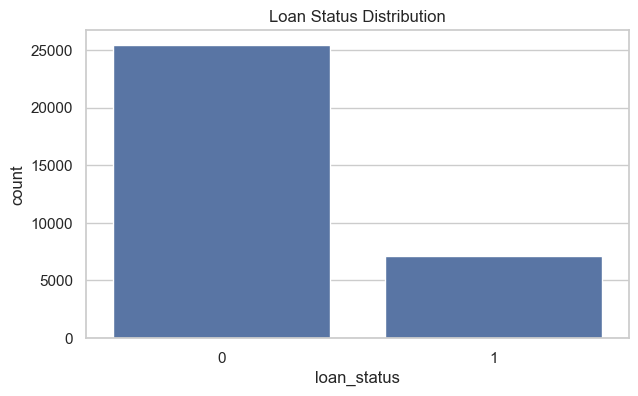

In [9]:
plt.figure(figsize=(7,4))
sns.countplot(x='loan_status', data=df_clean)
plt.title("Loan Status Distribution")
plt.show()

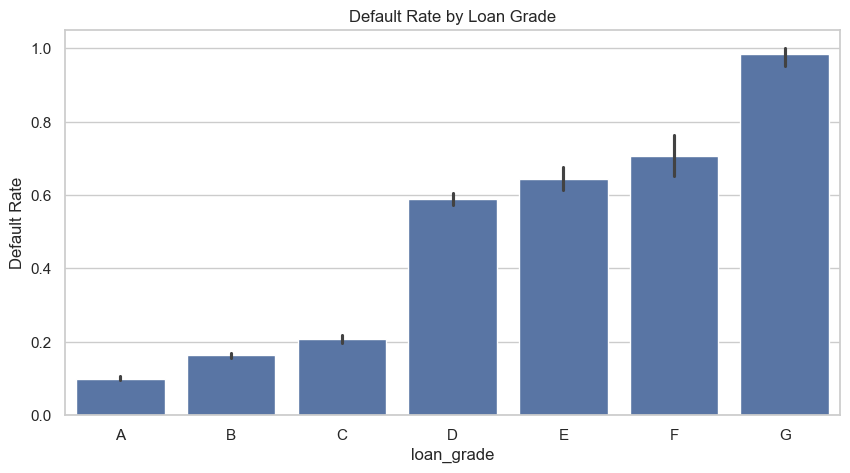

In [10]:
plt.figure(figsize=(10,5))
sns.barplot(x='loan_grade', y='loan_status', data=df_clean, order=sorted(df_clean['loan_grade'].unique()))
plt.title("Default Rate by Loan Grade")
plt.ylabel("Default Rate")
plt.show()

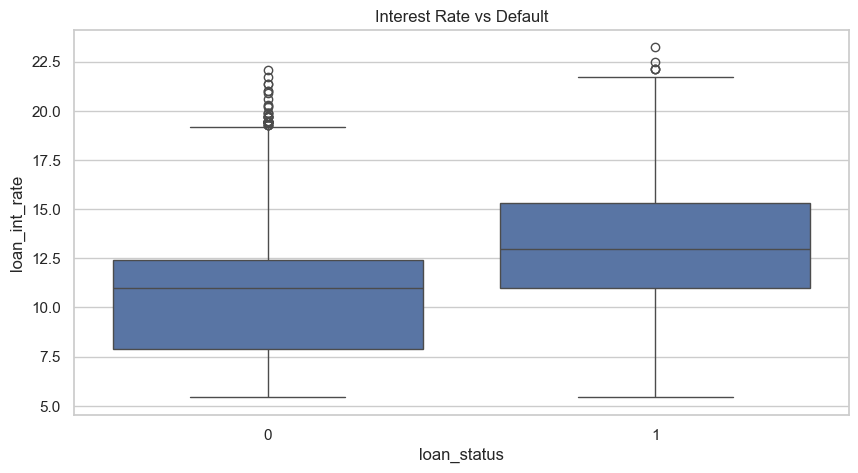

In [11]:
plt.figure(figsize=(10,5))
sns.boxplot(x='loan_status', y='loan_int_rate', data=df_clean)
plt.title("Interest Rate vs Default")
plt.show()

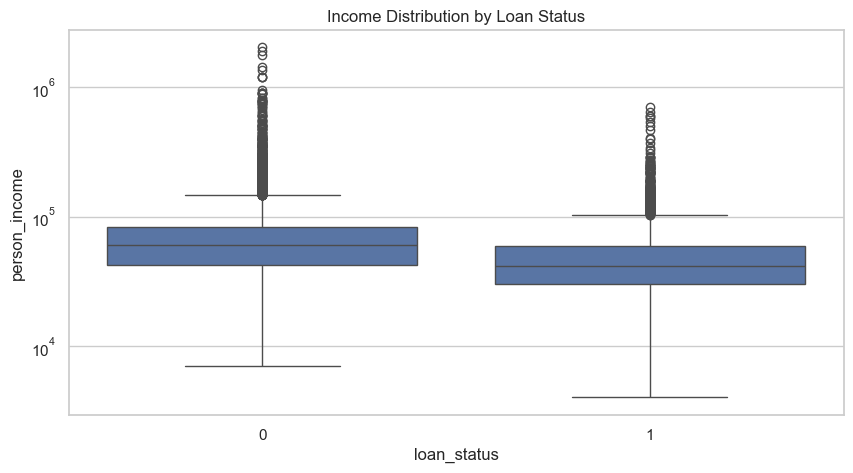

In [12]:
plt.figure(figsize=(10,5))
sns.boxplot(x='loan_status', y='person_income', data=df_clean)
plt.yscale('log')
plt.title("Income Distribution by Loan Status")
plt.show()

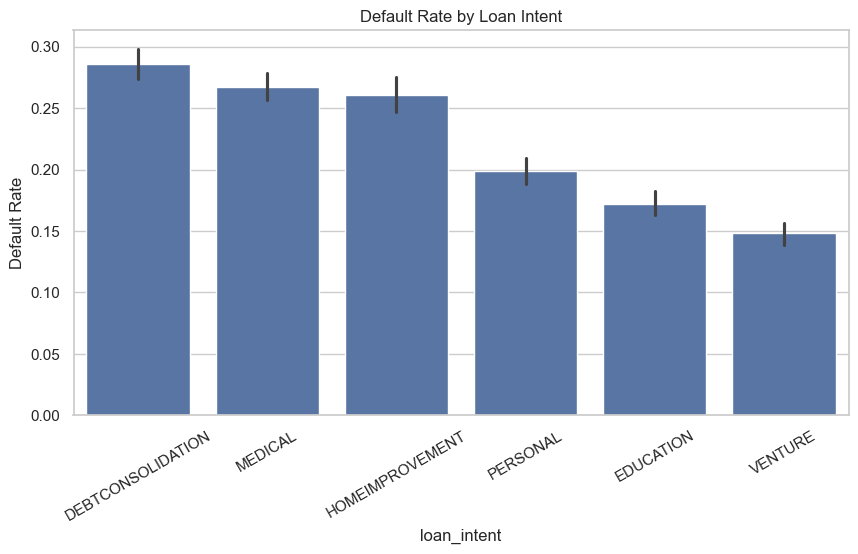

In [13]:
# wanted to see how loan purpose affects default - turns out it matters quite a bit
plt.figure(figsize=(10,5))
intent_order = df_clean.groupby('loan_intent')['loan_status'].mean().sort_values(ascending=False).index
sns.barplot(x='loan_intent', y='loan_status', data=df_clean, order=intent_order)
plt.title("Default Rate by Loan Intent")
plt.ylabel("Default Rate")
plt.xticks(rotation=30)
plt.show()

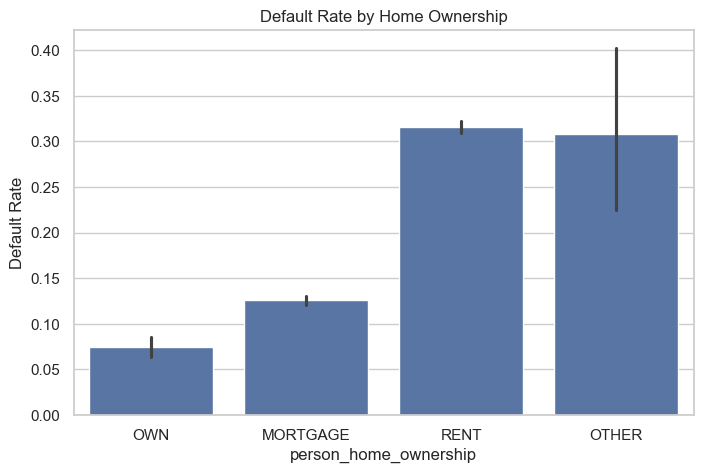

In [14]:
# home ownership - renters vs owners
plt.figure(figsize=(8,5))
sns.barplot(x='person_home_ownership', y='loan_status', data=df_clean)
plt.title("Default Rate by Home Ownership")
plt.ylabel("Default Rate")
plt.show()

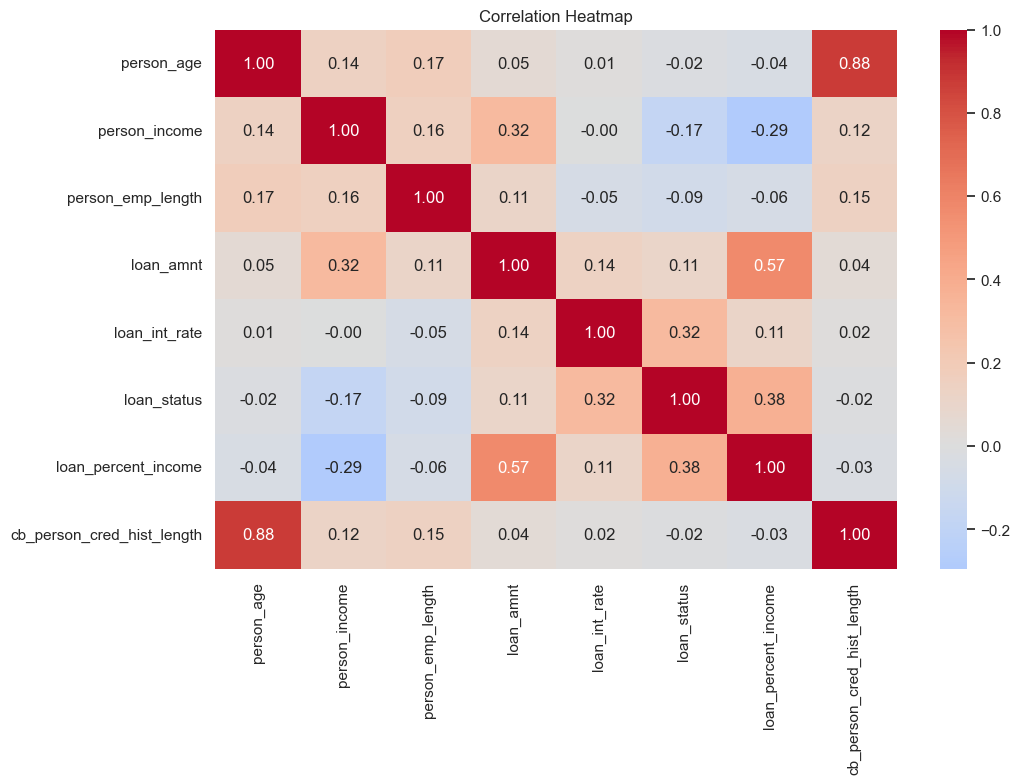

In [15]:
# correlation
num_cols = df_clean.select_dtypes(include=np.number).columns
plt.figure(figsize=(11,7))
sns.heatmap(df_clean[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

### Feature Engineering

Creating some extra features that might help the model and also useful for the dashboard later.

In [16]:
# loan to income
df_clean['loan_to_income'] = df_clean['loan_amnt'] / df_clean['person_income']

# early career people (usually higher risk)
df_clean['early_career'] = (df_clean['person_emp_length'] <= 2).astype(int)

# high interest flag
df_clean['high_int_rate'] = (df_clean['loan_int_rate'] > df_clean['loan_int_rate'].median()).astype(int)

# simple debt burden
df_clean['debt_burden'] = df_clean['loan_amnt'] / (df_clean['person_income'] * (df_clean['person_emp_length'] + 1))

# how much loan relative to credit history - shorter history + bigger loan = risky
df_clean['loan_to_cred_hist'] = df_clean['loan_amnt'] / (df_clean['cb_person_cred_hist_length'] + 1)

# employment stability groups
df_clean['emp_stability'] = pd.cut(df_clean['person_emp_length'],
                                   bins=[-1, 1, 3, 7, 100],
                                   labels=['Unstable', 'Low', 'Medium', 'Stable'])

# age groups
df_clean['age_group'] = pd.cut(df_clean['person_age'],
                               bins=[0, 25, 35, 45, 60, 100],
                               labels=['<25', '25-35', '35-45', '45-60', '60+'])

# income groups
df_clean['income_group'] = pd.qcut(df_clean['person_income'], q=4, labels=['Low', 'Mid-Low', 'Mid-High', 'High'])

# credit history length groups
df_clean['cred_hist_group'] = pd.cut(df_clean['cb_person_cred_hist_length'],
                                     bins=[-1, 3, 7, 15, 50],
                                     labels=['Very Short', 'Short', 'Medium', 'Long'])

print("New features added")
df_clean.head()

New features added


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_to_income,early_career,high_int_rate,debt_burden,loan_to_cred_hist,emp_stability,age_group,income_group,cred_hist_group
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,0.104167,0,1,0.017361,333.333333,Medium,<25,Low,Very Short
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,0.572917,1,1,0.286458,1375.000000,Unstable,<25,Low,Very Short
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,0.534351,0,1,0.106870,11666.666667,Medium,<25,Mid-High,Very Short
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,0.643382,0,1,0.071487,7000.000000,Stable,<25,Mid-Low,Short
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,0.252525,1,0,0.084175,833.333333,Low,<25,Low,Very Short


In [17]:
print("Default rate by early_career:")
print(df_clean.groupby('early_career')['loan_status'].mean())

print("\nDefault rate by income_group:")
print(df_clean.groupby('income_group')['loan_status'].mean())

print("\nDefault rate by emp_stability:")
print(df_clean.groupby('emp_stability')['loan_status'].mean())

Default rate by early_career:
early_career
0    0.191975
1    0.270569
Name: loan_status, dtype: float64

Default rate by income_group:
income_group
Low         0.397007
Mid-Low     0.213218
Mid-High    0.170620
High        0.091188
Name: loan_status, dtype: float64

Default rate by emp_stability:
emp_stability
Unstable    0.278245
Low         0.230453
Medium      0.203214
Stable      0.167615
Name: loan_status, dtype: float64


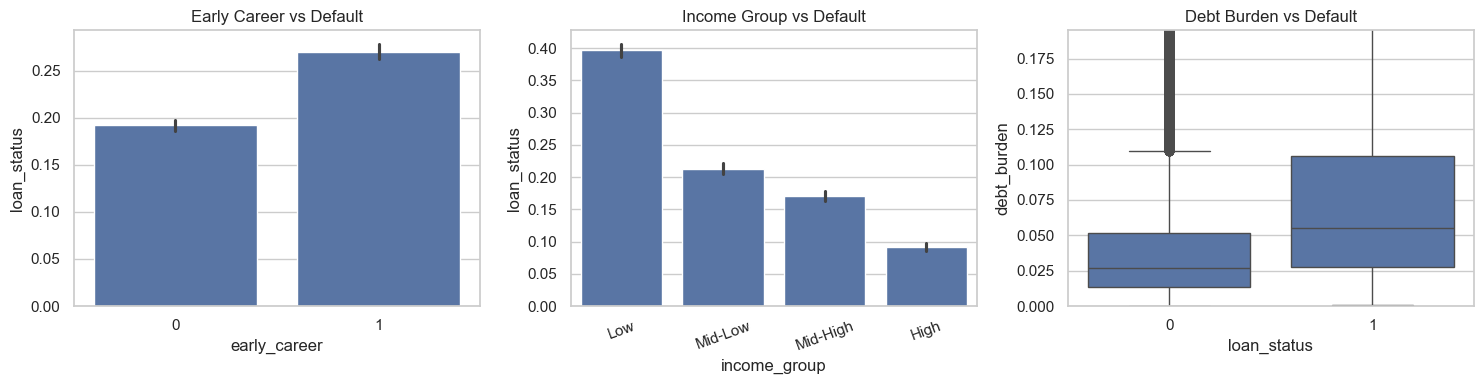

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.barplot(x='early_career', y='loan_status', data=df_clean, ax=axes[0])
axes[0].set_title("Early Career vs Default")

sns.barplot(x='income_group', y='loan_status', data=df_clean, ax=axes[1])
axes[1].set_title("Income Group vs Default")
axes[1].tick_params(axis='x', rotation=20)

sns.boxplot(x='loan_status', y='debt_burden', data=df_clean, ax=axes[2])
axes[2].set_title("Debt Burden vs Default")
axes[2].set_ylim(0, df_clean['debt_burden'].quantile(0.95))

plt.tight_layout()
plt.show()

In [19]:
print("Final shape:", df_clean.shape)
print(df_clean.columns.tolist())

# quick recap
orig = df.shape[0]
final = df_clean.shape[0]
new_feats = df_clean.shape[1] - df.shape[1]
print(f"\n--- Summary ---")
print(f"Started with {orig} rows, ended with {final} (dropped {orig - final} outliers)")
print(f"Added {new_feats} new features")
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")

# saving the cleaned data
df_clean.to_csv('../data/processed/loan_data_cleaned.csv', index=False)
print("\nSaved to data/processed/loan_data_cleaned.csv")

Final shape: (32572, 21)
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'loan_to_income', 'early_career', 'high_int_rate', 'debt_burden', 'loan_to_cred_hist', 'emp_stability', 'age_group', 'income_group', 'cred_hist_group']

--- Summary ---
Started with 32581 rows, ended with 32572 (dropped 9 outliers)
Added 9 new features
Missing values remaining: 0



Saved to data/processed/loan_data_cleaned.csv
